# Flood Emergency Routing — Shortest Path Analysis
**Discrete Mathematics Project | Team 4 — Khoo Henry & JiaYing Lai**

**Problem:** Find the optimal route for rescue teams from their base to critical destinations in Wrocław Dolnośląskie during varying flood severity levels.

**Model:** Directed weighted graph $G = (V, E, w)$ where edge weight is:
$$w(u,v) = \text{base\_time}(u,v) \times (1 + \text{flood\_factor}(u,v))$$

| Flood Factor | Level | Meaning |
|:---:|:---:|:---|
| 0 | Clear | Road fully passable |
| 0.5 | Moderate | Road slowed — travel time increases by 50% |
| inf | Severe | Road blocked, impassable |

> **Note:** Travel times represent estimated **emergency vehicle** travel times in minutes. Roads are pre-assigned flood severity levels based on their proximity to the Odra river and historical flood risk data from Wrocław Dolnośląskie.

**Algorithm:** Dijkstra's Algorithm

In [103]:
import heapq
import warnings
warnings.filterwarnings('ignore')

import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display
import pandas as pd

%matplotlib inline
plt.rcParams['figure.dpi']       = 110
plt.rcParams['font.family']      = 'DejaVu Sans'
plt.rcParams['axes.facecolor']   = 'white'
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['text.color']       = 'black'
plt.rcParams['axes.edgecolor']   = '#cccccc'

print('>>Libraries loaded successfully')

>>Libraries loaded successfully


In [110]:
#Specify the parameters and also for tweaking them

SCENARIO    = 2
SOURCE      = 'RescueBase'
DESTINATION = 'Checkpoint_North'

SCENARIO_LABELS = {
    0: 'Scenario 0 — Clear (No Flood)',
    1: 'Scenario 1 — Moderate Flood',
    2: 'Scenario 2 — Severe Flood',
}

NODE_POSITIONS = {
    'RescueBase'         : (0.0,  2.5),
    'Politechnika Wroc.' : (1.5,  3.5),
    'Most_Grunwaldzki'   : (2.5,  3.0),
    'Ostrow_Tumski'      : (3.5,  4.2),
    'Rynek'              : (3.5,  2.5),
    'Dworzec_Głowny'     : (3.5,  1.0),
    'SideStreet_A'       : (1.5,  1.5),
    'SideStreet_B'       : (1.5,  0.5),
    'ResidentialZone_A'  : (2.5,  1.8),
    'ResidentialZone_B'  : (0.8,  4.2),
    'WaterPlant'         : (0.3, -0.2),
    'Checkpoint_North'   : (4.8,  4.2),
    'Checkpoint_East'    : (5.0,  2.5),
    'CentralHospital'    : (6.0,  3.5),
    'NorthShelter'       : (6.0,  5.2),
    'FireStation'        : (6.0,  1.5),
}

INF = float('inf')

EDGE_DATA = [
    ('RescueBase',         'Politechnika Wroc.',   8,   0,   0,    0   ),
    ('RescueBase',         'SideStreet_A',         6,   0,   0,    0   ),
    ('RescueBase',         'ResidentialZone_B',    5,   0,   0.5,  0.5 ),
    ('RescueBase',         'WaterPlant',           7,   0,   0,    0   ),
    ('Politechnika Wroc.', 'Most_Grunwaldzki',     5,   0,   0.5,  INF ),
    ('Politechnika Wroc.', 'ResidentialZone_B',    4,   0,   0.5,  INF ),
    ('ResidentialZone_B',  'Ostrow_Tumski',        6,   0,   0.5,  INF ),
    ('Most_Grunwaldzki',   'Ostrow_Tumski',        4,   0,   0.5,  INF ),
    ('Most_Grunwaldzki',   'Rynek',                7,   0,   0.5,  INF ),
    ('Ostrow_Tumski',      'Checkpoint_North',     5,   0,   0.5,  INF ),
    ('Ostrow_Tumski',      'Rynek',                6,   0,   0.5,  INF ),
    ('WaterPlant',         'SideStreet_B',         4,   0,   0.5,  INF ),
    ('WaterPlant',         'Dworzec_Głowny',       10,  0,   0.5,  0.5 ),
    ('SideStreet_B',       'SideStreet_A',         3,   0,   0.5,  0.5 ),
    ('SideStreet_A',       'ResidentialZone_A',    5,   0,   0,    0.5 ),
    ('SideStreet_A',       'Dworzec_Głowny',       9,   0,   0,    0   ),
    ('ResidentialZone_A',  'Rynek',                6,   0,   0,    0.5 ),
    ('ResidentialZone_A',  'Dworzec_Głowny',       5,   0,   0,    0   ),
    ('Rynek',              'Checkpoint_North',     6,   0,   0,    0   ),
    ('Rynek',              'Checkpoint_East',      5,   0,   0,    0   ),
    ('Dworzec_Głowny',     'ResidentialZone_A',    5,   0,   0,    0   ),
    ('Dworzec_Głowny',     'Rynek',                7,   0,   0,    0   ),
    ('Dworzec_Głowny',     'Checkpoint_East',      8,   0,   0,    0   ),
    ('Dworzec_Głowny',     'FireStation',          10,  0,   0,    0   ),
    ('Checkpoint_North',   'NorthShelter',         7,   0,   0,    0   ),
    ('Checkpoint_North',   'CentralHospital',      8,   0,   0,    0   ),
    ('Checkpoint_North',   'Checkpoint_East',      5,   0,   0,    0   ),
    ('Checkpoint_East',    'CentralHospital',      6,   0,   0,    0   ),
    ('Checkpoint_East',    'FireStation',          7,   0,   0,    0   ),
    ('Checkpoint_East',    'NorthShelter',         9,   0,   0,    0   ),
]

scenario_col = {0: 3, 1: 4, 2: 5}
col          = scenario_col[SCENARIO]

graph     = {node: [] for node in NODE_POSITIONS}
edge_info = []

for row in EDGE_DATA:
    u            = row[0]
    v            = row[1]
    base_time    = row[2]
    flood_factor = row[col]
    weight       = base_time * (1 + flood_factor)
    graph[u].append((v, weight))
    edge_info.append((u, v, base_time, flood_factor, weight))

print(f'>> Graph built: {SCENARIO_LABELS[SCENARIO]}')
# print(f'Nodes: {len(NODE_POSITIONS)}  |  Edges: {len(edge_info)}')
print(f'>> Query: {SOURCE}  →  {DESTINATION}')

>> Graph built: Scenario 2 — Severe Flood
>> Query: RescueBase  →  Checkpoint_North


In [111]:
def dijkstra(graph, source, destination):
    """
    Dijkstra's shortest path algorithm using a min-priority queue.

    Parameters
    ----------
    graph       : dict — adjacency list {node: [(neighbour, weight), ...]}
    source      : str  — starting node
    destination : str  — target node

    Returns
    -------
    dist          : dict — shortest distance from source to every node
    visited_order : list — nodes settled in order (used by animation)
    path          : list — reconstructed shortest path [source, ..., destination]
                           empty if destination is unreachable
    """
    dist = {node: float('inf') for node in graph}
    dist[source] = 0

    prev = {node: None for node in graph}

    priority_queue = [(0, source)]
    settled        = set()
    visited_order  = []

    while priority_queue:
        current_dist, u = heapq.heappop(priority_queue)

        if u in settled:
            continue

        settled.add(u)
        visited_order.append(u)

        if u == destination:
            break

        for v, weight in graph[u]:
            if weight == float('inf'):
                continue

            candidate = dist[u] + weight

            if candidate < dist[v]:
                dist[v] = candidate
                prev[v] = u
                heapq.heappush(priority_queue, (candidate, v))

    path = []
    node = destination
    while node is not None:
        path.append(node)
        node = prev[node]
    path.reverse()

    if not path or path[0] != source:
        path = []

    return dist, visited_order, path


print('>> Dijkstra function defined and ready')

>> Dijkstra function defined and ready


  Scenario 2 — Severe Flood
  Route : RescueBase -> SideStreet_A -> Dworzec_Głowny -> Rynek -> Checkpoint_North
  Cost  : 28.0 minutes
  Dijkstra settled 11 node(s) before reaching destination


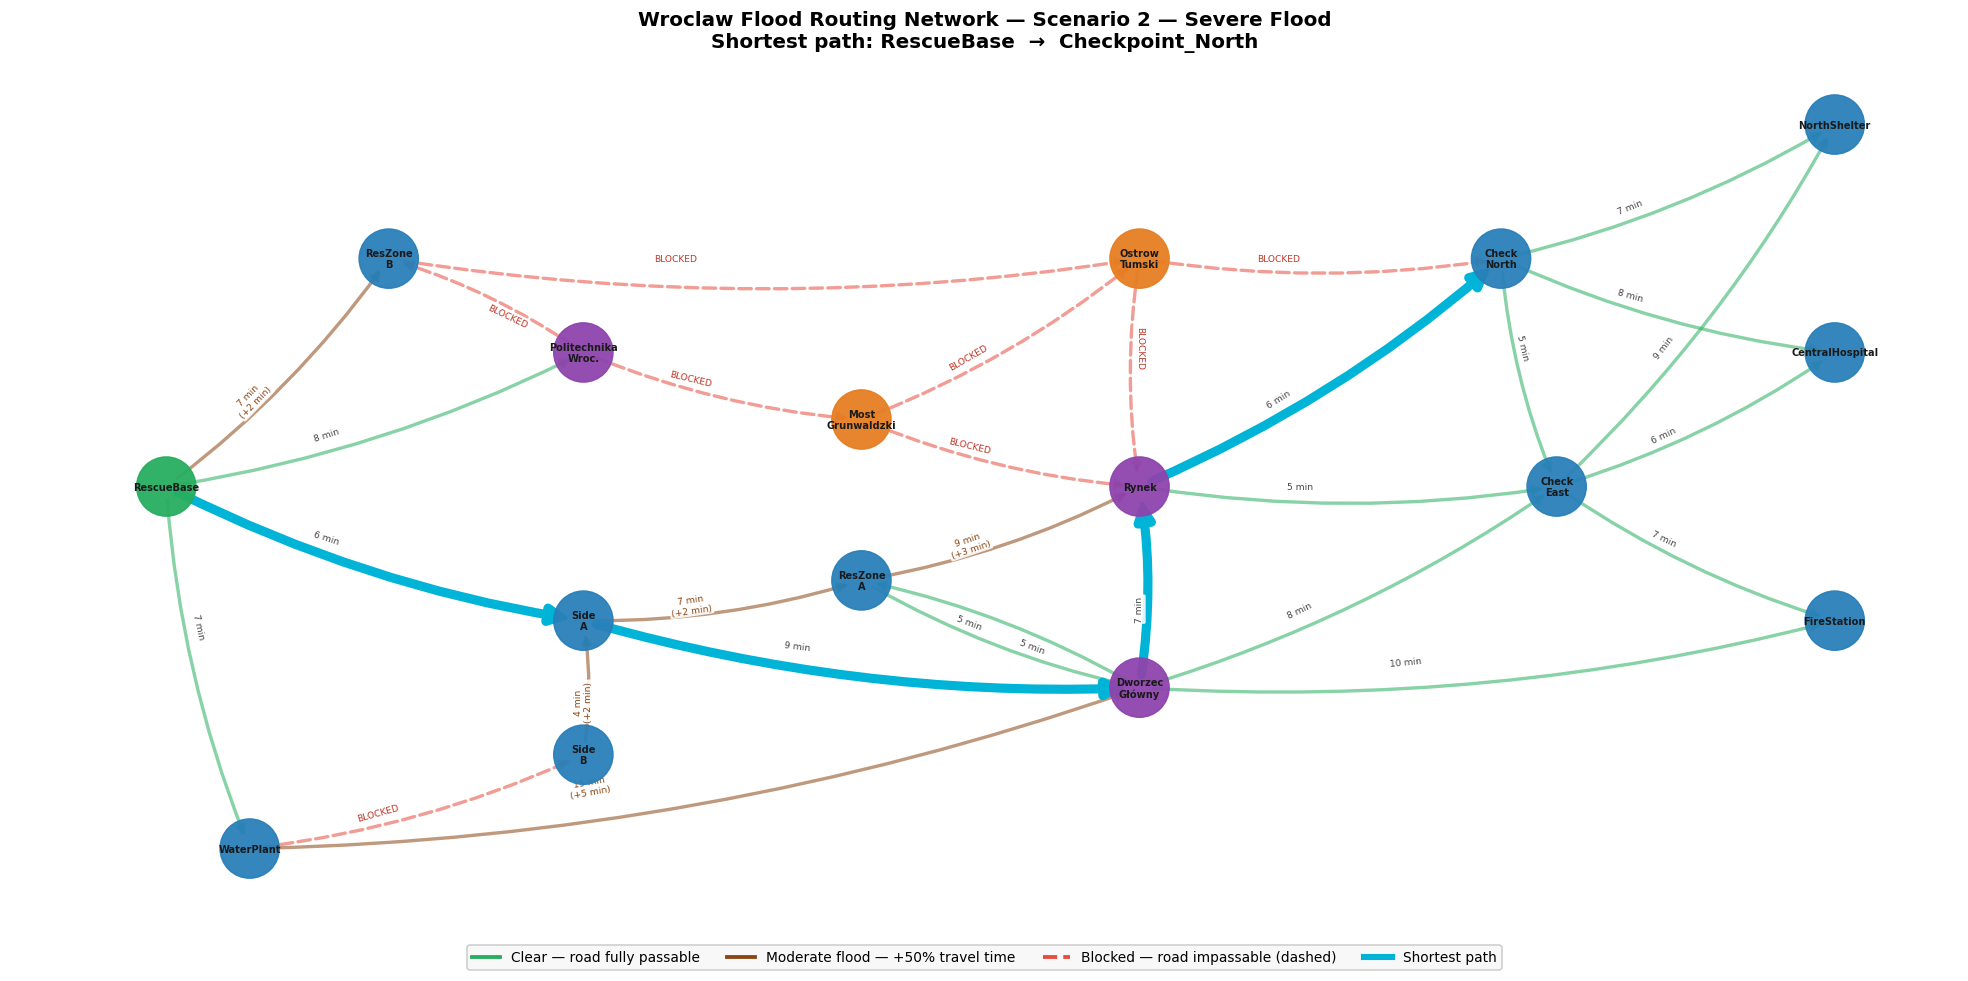


 >>> (Dijkstra) step by step Animation graph ...


From,To,Base Time (min),Flood Factor,Formula,Weight (min)
RescueBase,SideStreet_A,6,Clear (0),6 x (1 + 0) = 6.0,6
SideStreet_A,Dworzec_Głowny,9,Clear (0),9 x (1 + 0) = 9.0,9
Dworzec_Głowny,Rynek,7,Clear (0),7 x (1 + 0) = 7.0,7
Rynek,Checkpoint_North,6,Clear (0),6 x (1 + 0) = 6.0,6


  Total base time (no flood) : 28 min
  Total travel time (actual) : 28.0 min
  Flood time penalty         : +0.0 min


Scenario,Shortest Path,Total Cost (min),Hops,Route Changed?
Scenario 0 — Clear (No Flood),RescueBase -> ResidentialZone_B -> Ostrow_Tumski -> Checkpoint_North,16.0,3,Baseline
Scenario 1 — Moderate Flood,RescueBase -> SideStreet_A -> ResidentialZone_A -> Rynek -> Checkpoint_North,23.0,4,Yes
Scenario 2 — Severe Flood,RescueBase -> SideStreet_A -> Dworzec_Głowny -> Rynek -> Checkpoint_North,28.0,4,Yes


In [113]:
# (Visualizations)constructing the cosmetic parts graphs & tables ...

dist, visited_order, path = dijkstra(graph, SOURCE, DESTINATION)

total_cost = dist[DESTINATION]
reachable  = total_cost < float('inf') and len(path) > 0

print('=' * 62)
print(f'  {SCENARIO_LABELS[SCENARIO]}')
print('=' * 62)
if reachable:
    print(f'  Route : {" -> ".join(path)}')
    print(f'  Cost  : {total_cost:.1f} minutes')
    print(f'  Dijkstra settled {len(visited_order)} node(s) before reaching destination')
else:
    print(f'  {DESTINATION} is UNREACHABLE under this flood scenario.')
print('=' * 62)


G = nx.DiGraph()
G.add_nodes_from(NODE_POSITIONS.keys())
for u, v, base, ff, w in edge_info:
    G.add_edge(u, v, weight=w, flood_factor=ff, base=base)

pos = NODE_POSITIONS

def get_node_color(n):
    if n == SOURCE:
        return '#27ae60'
    if n in ['Most_Grunwaldzki', 'Ostrow_Tumski']:
        return '#e67e22'
    if n in ['Politechnika Wroc.', 'Rynek', 'Dworzec_Głowny']:
        return '#8e44ad'
    return '#2980b9'

node_colors = [get_node_color(n) for n in G.nodes()]

def get_edge_color(ff):
    if ff == 0:   return '#27ae60'
    if ff == 0.5: return '#8B4513'
    return '#e74c3c'

PATH_COLOR = '#00b4d8'
path_edges = set(zip(path[:-1], path[1:])) if reachable else set()

short_labels = {
    n: (n.replace('Politechnika Wroc.', 'Politechnika\nWroc.')
         .replace('ResidentialZone_', 'ResZone\n')
         .replace('Checkpoint_', 'Check\n')
         .replace('SideStreet_', 'Side\n')
         .replace('Most_Grunwaldzki', 'Most\nGrunwaldzki')
         .replace('Dworzec_Głowny', 'Dworzec\nGłówny')
         .replace('Ostrow_Tumski', 'Ostrow\nTumski'))
    for n in G.nodes()
}


fig_s, ax_s = plt.subplots(figsize=(18, 9))
fig_s.patch.set_facecolor('white')
ax_s.set_facecolor('white')
ax_s.set_title(
    f'Wroclaw Flood Routing Network — {SCENARIO_LABELS[SCENARIO]}\n'
    f'Shortest path: {SOURCE}  →  {DESTINATION}',
    color='black', fontsize=13, pad=14, fontweight='bold'
)

for u, v in G.edges():
    ff           = G[u][v]['flood_factor']
    is_path_edge = (u, v) in path_edges
    nx.draw_networkx_edges(
        G, pos, edgelist=[(u, v)], ax=ax_s,
        edge_color=[get_edge_color(ff)],
        style='dashed' if ff == INF else 'solid',
        width=3.0 if is_path_edge else 2.2,
        alpha=1.0 if is_path_edge else 0.55,
        arrows=True, arrowstyle='-|>',
        arrowsize=18 if is_path_edge else 13,
        connectionstyle='arc3,rad=0.08'
    )

if reachable:
    nx.draw_networkx_edges(
        G, pos, edgelist=list(path_edges), ax=ax_s,
        edge_color=PATH_COLOR, width=6.0, alpha=1.0,
        arrows=True, arrowstyle='-|>', arrowsize=22,
        connectionstyle='arc3,rad=0.08'
    )

clear_labels    = {}
moderate_labels = {}
blocked_labels  = {}

for u, v, base, ff, w in edge_info:
    if ff == INF:
        blocked_labels[(u, v)]  = 'BLOCKED'
    elif ff == 0:
        clear_labels[(u, v)]    = f'{int(w)} min'
    else:
        penalty = int(round(w - base))
        moderate_labels[(u, v)] = f'{int(w)} min\n(+{penalty} min)'

lbl_kw = dict(
    ax        = ax_s,
    font_size = 6,
    label_pos = 0.38,
    bbox      = dict(boxstyle='round,pad=0.18', facecolor='white', alpha=0.88, edgecolor='none')
)
if clear_labels:
    nx.draw_networkx_edge_labels(G, pos, edge_labels=clear_labels,    font_color='#444444', **lbl_kw)
if moderate_labels:
    nx.draw_networkx_edge_labels(G, pos, edge_labels=moderate_labels, font_color='#8B4513', **lbl_kw)
if blocked_labels:
    nx.draw_networkx_edge_labels(G, pos, edge_labels=blocked_labels,  font_color='#c0392b', **lbl_kw)

nx.draw_networkx_nodes(G, pos, ax=ax_s, node_color=node_colors, node_size=1500, alpha=0.95)
nx.draw_networkx_labels(G, pos, labels=short_labels, ax=ax_s, font_size=6.5, font_color='#1a1a1a', font_weight='bold')

legend_lines = [
    Line2D([0],[0], color='#27ae60', linewidth=2.5, linestyle='-',  label='Clear — road fully passable'),
    Line2D([0],[0], color='#8B4513', linewidth=2.5, linestyle='-',  label='Moderate flood — +50% travel time'),
    Line2D([0],[0], color='#e74c3c', linewidth=2.5, linestyle='--', label='Blocked — road impassable (dashed)'),
    Line2D([0],[0], color=PATH_COLOR, linewidth=4.0, linestyle='-', label='Shortest path'),
]
ax_s.legend(handles=legend_lines, loc='upper center', bbox_to_anchor=(0.5, -0.04),
            ncol=4, facecolor='#f8f8f8', edgecolor='#cccccc', fontsize=9, framealpha=1.0)

ax_s.axis('off')
plt.tight_layout()
plt.show()


print('\n >>> (Dijkstra) step by step Animation graph ...')

fig_a, ax_a  = plt.subplots(figsize=(18, 9))
fig_a.patch.set_facecolor('white')
nodes_list   = list(G.nodes())

def draw_frame(frame_idx):
    ax_a.clear()
    ax_a.set_facecolor('white')
    ax_a.axis('off')

    settled_so_far = set(visited_order[:frame_idx])
    just_settled   = visited_order[frame_idx - 1] if frame_idx > 0 else None
    is_final_frame = (frame_idx == len(visited_order))

    frame_colors = []
    for n in nodes_list:
        if is_final_frame and reachable and n in path:
            frame_colors.append(PATH_COLOR)
        elif n == just_settled:
            frame_colors.append('#f1c40f')
        elif n in settled_so_far:
            frame_colors.append('#1abc9c')
        else:
            frame_colors.append('#bdc3c7')

    for u, v in G.edges():
        ff = G[u][v]['flood_factor']
        nx.draw_networkx_edges(
            G, pos, edgelist=[(u, v)], ax=ax_a,
            edge_color=[get_edge_color(ff)],
            style='dashed' if ff == INF else 'solid',
            width=2.0, alpha=0.30,
            arrows=True, arrowstyle='-|>', arrowsize=11,
            connectionstyle='arc3,rad=0.08'
        )

    if is_final_frame and reachable:
        nx.draw_networkx_edges(
            G, pos, edgelist=list(path_edges), ax=ax_a,
            edge_color=PATH_COLOR, width=6.0, alpha=1.0,
            arrows=True, arrowstyle='-|>', arrowsize=22,
            connectionstyle='arc3,rad=0.08'
        )

    nx.draw_networkx_nodes(G, pos, ax=ax_a, node_color=frame_colors, node_size=1450)
    nx.draw_networkx_labels(G, pos, labels=short_labels, ax=ax_a, font_size=6.5, font_color='#1a1a1a', font_weight='bold')

    if frame_idx == 0:
        step_label = 'Initialising — all distances set to infinity, source distance = 0'
    elif is_final_frame and reachable:
        step_label = f'Done — shortest path found: {total_cost:.1f} min'
    elif is_final_frame:
        step_label = f'{DESTINATION} is unreachable under this scenario'
    else:
        step_label = f'Step {frame_idx}: Settled "{just_settled}"  |  shortest distance = {dist[just_settled]:.1f} min'

    ax_a.set_title(
        f'Dijkstra Step-by-Step — {SCENARIO_LABELS[SCENARIO]}\n{step_label}',
        color='black', fontsize=11, fontweight='bold'
    )

    state_legend = [
        mpatches.Patch(color='#bdc3c7', label='Not yet reached'),
        mpatches.Patch(color='#f1c40f', label='Just settled'),
        mpatches.Patch(color='#1abc9c', label='Settled'),
        mpatches.Patch(color=PATH_COLOR, label='Shortest path'),
    ]
    ax_a.legend(handles=state_legend, loc='upper center', bbox_to_anchor=(0.5, -0.02),
                ncol=4, facecolor='#f8f8f8', edgecolor='#cccccc', fontsize=9, framealpha=1.0)

total_frames = len(visited_order) + 1
anim = FuncAnimation(fig_a, draw_frame, frames=total_frames, interval=950, repeat=True)
plt.close(fig_a)
display(HTML(anim.to_jshtml()))


display(HTML('''
<div style="
    background-color: #2c3e50; color: white; font-size: 14px; font-weight: bold;
    padding: 10px 16px; margin-top: 36px; margin-bottom: 0px; border-radius: 4px 4px 0 0;
">TABLE 1 — Edge Breakdown of Shortest Path</div>
'''))

if reachable:
    path_rows  = []
    total_base = 0
    total_wt   = 0

    for i in range(len(path) - 1):
        u, v  = path[i], path[i + 1]
        match = next((r for r in edge_info if r[0] == u and r[1] == v), None)
        if match:
            _, _, base, ff, w = match
            ff_label = {0: 'Clear (0)', 0.5: 'Moderate (0.5)'}.get(ff, 'Blocked (inf)')
            path_rows.append({
                'From'            : u,
                'To'              : v,
                'Base Time (min)' : base,
                'Flood Factor'    : ff_label,
                'Formula'         : f'{base} x (1 + {ff if ff != INF else "inf"}) = {w:.1f}',
                'Weight (min)'    : round(w, 1),
            })
            total_base += base
            total_wt   += w

    styled_path = (pd.DataFrame(path_rows).style
        .set_table_styles([
            {'selector': 'th', 'props': [('background-color','#34495e'),('color','white'),
                ('padding','8px 14px'),('text-align','left'),('border-bottom','2px solid #2c3e50')]},
            {'selector': 'td', 'props': [('background-color','#ffffff'),('color','#1a1a1a'),
                ('padding','7px 14px'),('border-bottom','1px solid #e0e0e0')]},
            {'selector': 'tr:hover td', 'props': [('background-color','#eaf4fb')]},
        ])
        .hide(axis='index')
    )
    display(styled_path)

    print(f'  Total base time (no flood) : {total_base} min')
    print(f'  Total travel time (actual) : {total_wt:.1f} min')
    print(f'  Flood time penalty         : +{total_wt - total_base:.1f} min')

else:
    display(HTML(f'<p style="padding:10px; color:#c0392b; background:#fde8e8;">'
                 f'{DESTINATION} is unreachable under {SCENARIO_LABELS[SCENARIO]}.</p>'))


display(HTML('''
<div style="
    background-color: #2c3e50; color: white; font-size: 14px; font-weight: bold;
    padding: 10px 16px; margin-top: 48px; margin-bottom: 0px; border-radius: 4px 4px 0 0;
">TABLE 2 — Scenario Comparison: How does the route change as flood severity increases?</div>
'''))

comparison_rows = []
baseline_path   = []

for sc in [0, 1, 2]:
    sc_graph = {node: [] for node in NODE_POSITIONS}
    c = scenario_col[sc]
    for row in EDGE_DATA:
        u2, v2, bt, ff2 = row[0], row[1], row[2], row[c]
        sc_graph[u2].append((v2, bt * (1 + ff2)))

    sc_dist, _, sc_path = dijkstra(sc_graph, SOURCE, DESTINATION)
    sc_cost      = sc_dist[DESTINATION]
    sc_reachable = sc_cost < float('inf') and len(sc_path) > 0

    if sc == 0:
        route_changed = 'Baseline'
        baseline_path = sc_path
    else:
        route_changed = 'No' if sc_path == baseline_path else 'Yes'

    comparison_rows.append({
        'Scenario'         : SCENARIO_LABELS[sc],
        'Shortest Path'    : ' -> '.join(sc_path) if sc_reachable else 'UNREACHABLE',
        'Total Cost (min)' : f'{sc_cost:.1f}' if sc_reachable else 'inf',
        'Hops'             : len(sc_path) - 1 if sc_reachable else '—',
        'Route Changed?'   : route_changed,
    })

def highlight_row(row):
    base = 'color: #1a1a1a; padding: 7px 14px; border-bottom: 1px solid #e0e0e0;'
    if row['Total Cost (min)'] == 'inf':
        return [base + 'background-color: #fde8e8;'] * len(row)
    return [base + 'background-color: #ffffff;'] * len(row)

styled_comp = (pd.DataFrame(comparison_rows).style
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color','#34495e'),('color','white'),
            ('padding','8px 14px'),('text-align','left'),('border-bottom','2px solid #2c3e50')]},
        {'selector': 'tr:hover td', 'props': [('background-color','#eaf4fb')]},
    ])
    .apply(highlight_row, axis=1)
    .hide(axis='index')
)
display(styled_comp)